# Analyse des centrales électriques

Ce notebook nettoie le jeu de données, explore les centrales par pays et type de combustible, teste les différences de puissance, analyse l'évolution temporelle et illustre les résultats avec Pandas, NumPy, Matplotlib et Seaborn.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

# Chargement des données
df = pd.read_csv("global_power_plant_database.csv")

print("Dimensions initiales :", df.shape)
print("\nValeurs manquantes principales :")
print(df.isna().sum().sort_values(ascending=False).head(10))

# Conversion des colonnes numériques pertinentes
numeric_columns = [
    "capacity_mw",
    "latitude",
    "longitude",
    "commissioning_year",
    "year_of_capacity_data",
]
numeric_columns += [col for col in df.columns if col.startswith("generation_gwh_")]
numeric_columns += [col for col in df.columns if col.startswith("estimated_generation_gwh_")]

for column in numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

# Traitement des valeurs manquantes
categorical_columns = ["country", "country_long", "primary_fuel", "owner", "source", "geolocation_source"]
for column in categorical_columns:
    if column in df.columns:
        df[column] = df[column].fillna("Unknown")

for column in ["capacity_mw", "latitude", "longitude"]:
    df[column] = df[column].fillna(df[column].median())

if "commissioning_year" in df.columns:
    df["commissioning_year"] = df["commissioning_year"].fillna(df["commissioning_year"].median())

# Nettoyage des doublons et des lignes sans variable clé
df = df.drop_duplicates()
df = df.dropna(subset=["country_long", "primary_fuel", "capacity_mw"])

print("\nDimensions après nettoyage :", df.shape)
df.head()

Dimensions initiales : (34936, 36)

Valeurs manquantes principales :
other_fuel3            34844
other_fuel2            34660
other_fuel1            32992
generation_gwh_2013    28519
generation_gwh_2014    27710
generation_gwh_2015    26733
generation_gwh_2016    25792
generation_gwh_2017    25436
generation_gwh_2018    25299
generation_gwh_2019    25277
dtype: int64

Dimensions après nettoyage : (34936, 36)


C:\Users\HP\AppData\Local\Temp\ipykernel_7132\1653420377.py:10: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("global_power_plant_database.csv")


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


## Analyse exploratoire des données

Statistiques descriptives des colonnes numériques principales :
                                      mean       median          std
year_of_capacity_data          2018.218849  2019.000000     1.606428
commissioning_year             2002.213173  2007.000000    17.215166
generation_gwh_2015             762.368840    26.142000  2533.459828
estimated_generation_gwh_2017   716.443378    37.590000  2484.361200
generation_gwh_2016             693.149763    22.462389  2404.516759
generation_gwh_2017             661.834161    17.876500  2369.296957
generation_gwh_2014             656.863891    23.608500  2231.464288
generation_gwh_2013             592.696107    23.426000  2174.833482
generation_gwh_2018             517.320785    12.530000  1975.302686
generation_gwh_2019             423.922436    11.530000  1698.506485

Top 10 des pays par nombre de centrales :
country_long
United States of America    9833
China                       4235
United Kingdom              2751
Brazil                

C:\Users\HP\AppData\Local\Temp\ipykernel_7132\1456561423.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plants_by_country.values, y=plants_by_country.index, palette="Blues_r")


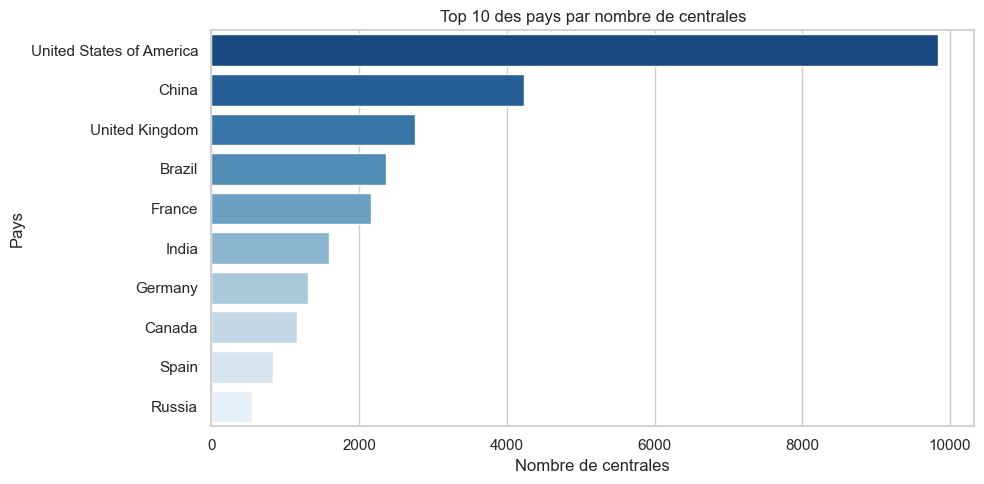


Répartition des centrales par type de combustible :
primary_fuel
Solar             10665
Hydro              7156
Wind               5344
Gas                3998
Coal               2330
Oil                2320
Biomass            1430
Waste              1068
Nuclear             195
Geothermal          189
Storage             135
Other                43
Cogeneration         41
Petcoke              12
Wave and Tidal       10
Name: count, dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_7132\1456561423.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plants_by_fuel.values, y=plants_by_fuel.index, palette="viridis")


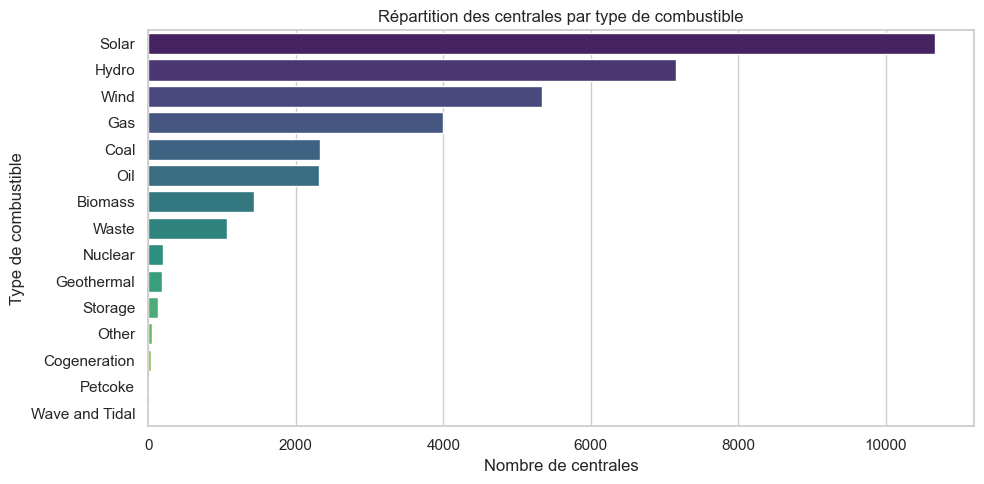

In [2]:
# Statistiques clés sur les colonnes numériques
numeric_summary = df.select_dtypes(include=[np.number]).agg(["mean", "median", "std"]).T
print("Statistiques descriptives des colonnes numériques principales :")
print(numeric_summary.sort_values("mean", ascending=False).head(10))

# Répartition des centrales électriques par pays
plants_by_country = df["country_long"].value_counts().head(10)
print("\nTop 10 des pays par nombre de centrales :")
print(plants_by_country)

plt.figure(figsize=(10, 5))
sns.barplot(x=plants_by_country.values, y=plants_by_country.index, palette="Blues_r")
plt.title("Top 10 des pays par nombre de centrales")
plt.xlabel("Nombre de centrales")
plt.ylabel("Pays")
plt.tight_layout()
plt.show()

# Répartition par type de combustible
plants_by_fuel = df["primary_fuel"].value_counts()
print("\nRépartition des centrales par type de combustible :")
print(plants_by_fuel)

plt.figure(figsize=(10, 5))
sns.barplot(x=plants_by_fuel.values, y=plants_by_fuel.index, palette="viridis")
plt.title("Répartition des centrales par type de combustible")
plt.xlabel("Nombre de centrales")
plt.ylabel("Type de combustible")
plt.tight_layout()
plt.show()

## Analyse statistique de la puissance de sortie

Statistiques NumPy par type de combustible :
                mean_capacity_mw  median_capacity_mw  std_capacity_mw  count
Nuclear              2091.855179          1888.00000      1300.162646    195
Coal                  843.579828           600.00000       887.996568   2330
Gas                   373.449375           147.50000       560.863990   3998
Petcoke               202.048125            65.48875       456.679766     12
Hydro                 147.171551            20.00000       549.770911   7156
Oil                   112.878754             9.00000       391.924545   2320
Cogeneration           98.731707            31.90000       279.950473     41
Other                  84.020000            40.00000       144.185002     43
Geothermal             67.130952            30.00000       114.337205    189
Wave and Tidal         55.220000             5.00000        96.235106     10

ANOVA: F = 967.4600, p-value = 0.000000
Conclusion: la puissance moyenne diffère significativement selon le

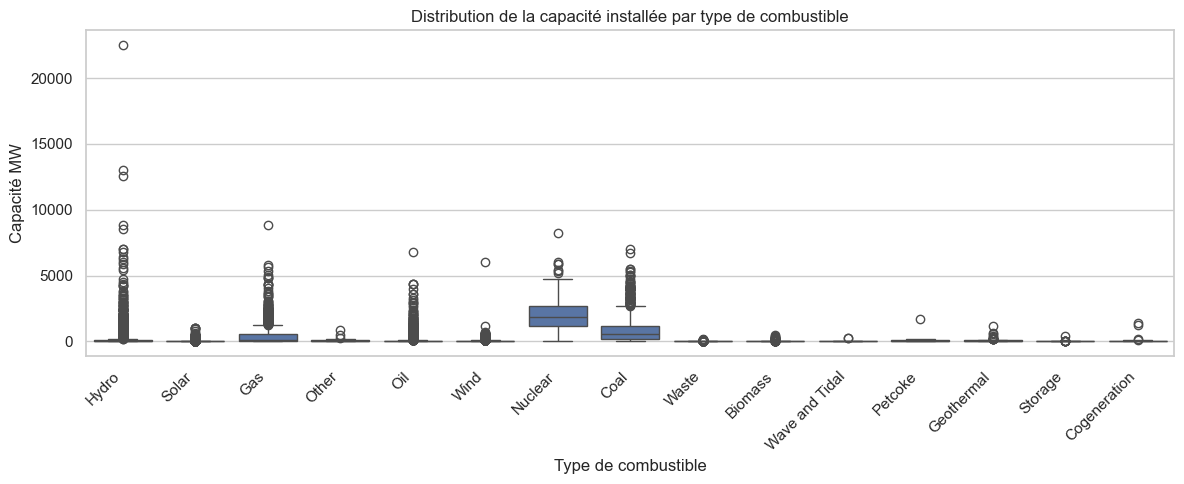

In [3]:
# Analyse de la puissance par type de combustible avec NumPy
fuel_groups = {
    fuel: group["capacity_mw"].dropna().to_numpy()
    for fuel, group in df.groupby("primary_fuel")
}

fuel_stats = pd.DataFrame({
    "mean_capacity_mw": {fuel: np.mean(values) for fuel, values in fuel_groups.items()},
    "median_capacity_mw": {fuel: np.median(values) for fuel, values in fuel_groups.items()},
    "std_capacity_mw": {fuel: np.std(values) for fuel, values in fuel_groups.items()},
    "count": {fuel: len(values) for fuel, values in fuel_groups.items()},
}).sort_values("mean_capacity_mw", ascending=False)

print("Statistiques NumPy par type de combustible :")
print(fuel_stats.head(10))

# Test d'hypothèse: la moyenne de capacité diffère-t-elle selon le combustible ?
valid_groups = [values for values in fuel_groups.values() if len(values) > 1]
f_stat, p_value = stats.f_oneway(*valid_groups)

print(f"\nANOVA: F = {f_stat:.4f}, p-value = {p_value:.6f}")
if p_value < 0.05:
    print("Conclusion: la puissance moyenne diffère significativement selon le type de combustible.")
else:
    print("Conclusion: aucune différence significative n'est mise en évidence au seuil de 5%.")

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="primary_fuel", y="capacity_mw")
plt.xticks(rotation=45, ha="right")
plt.title("Distribution de la capacité installée par type de combustible")
plt.xlabel("Type de combustible")
plt.ylabel("Capacité MW")
plt.tight_layout()
plt.show()

## Analyse des séries chronologiques

Nombre de centrales par année de mise en service :
commissioning_year
2011    617
2012    769
2013    688
2014    823
2015    821
2016    880
2017    782
2018    617
2019    599
2020    150
Name: count, dtype: int64


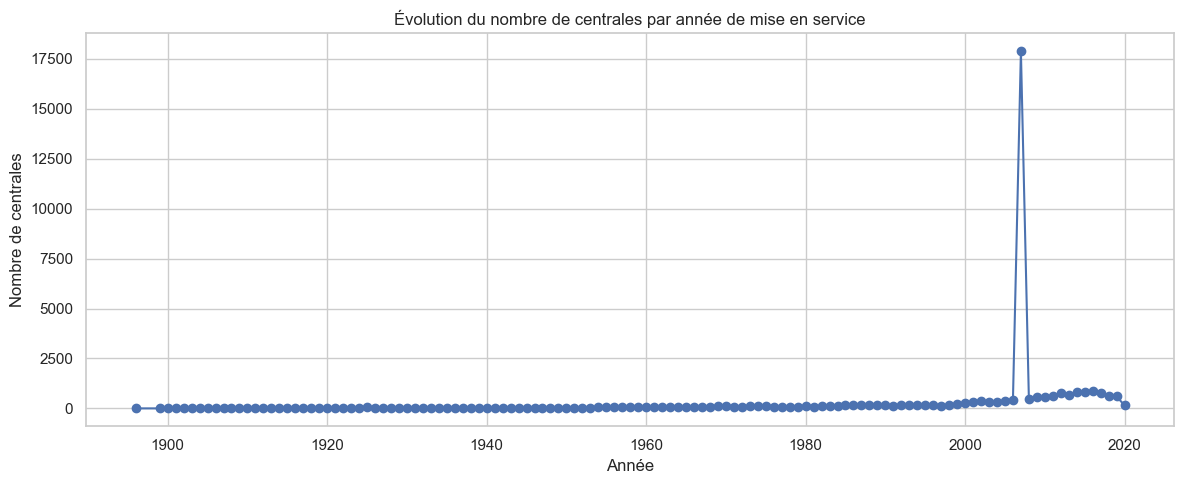


Composition des principaux combustibles au fil du temps :
primary_fuel        Coal   Gas  Hydro   Oil  Solar   Wind
commissioning_year                                       
2016                84.0  45.0   45.0  38.0  464.0  169.0
2017                46.0  48.0   22.0   5.0  523.0  105.0
2018                14.0  52.0    4.0   7.0  480.0   40.0
2019                 0.0  34.0    1.0   3.0  458.0   63.0
2020                 0.0   6.0    0.0   0.0  122.0   17.0


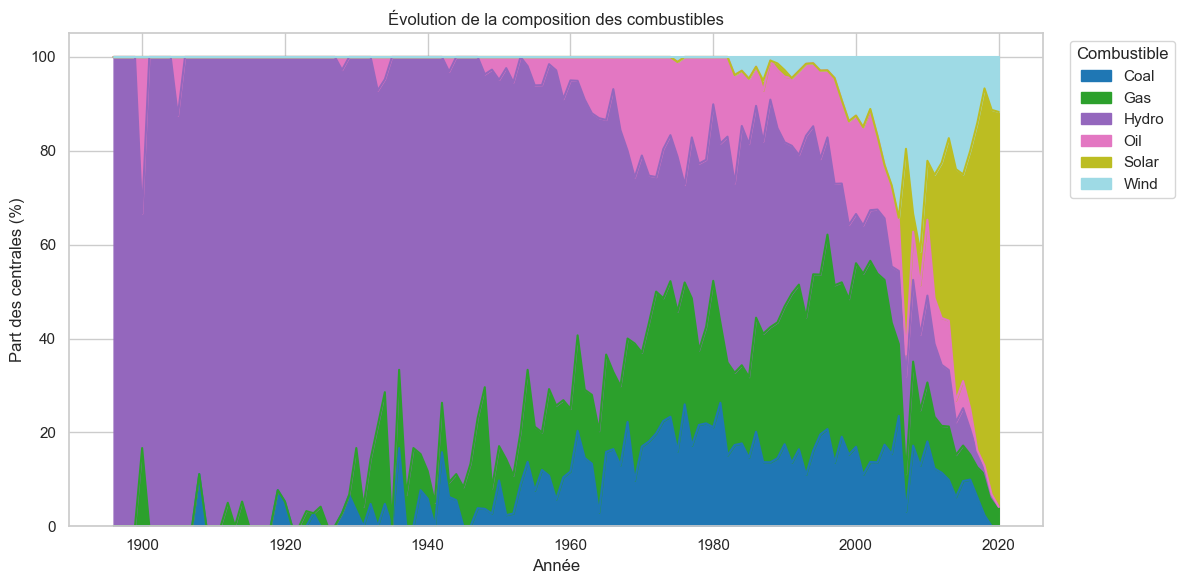

In [4]:
# Tendance des centrales mises en service au fil du temps
commissioning = df.dropna(subset=["commissioning_year"]).copy()
commissioning["commissioning_year"] = commissioning["commissioning_year"].astype(int)

plants_by_year = commissioning["commissioning_year"].value_counts().sort_index()
print("Nombre de centrales par année de mise en service :")
print(plants_by_year.tail(10))

plt.figure(figsize=(12, 5))
plt.plot(plants_by_year.index, plants_by_year.values, marker="o")
plt.title("Évolution du nombre de centrales par année de mise en service")
plt.xlabel("Année")
plt.ylabel("Nombre de centrales")
plt.tight_layout()
plt.show()

# Évolution de la composition des combustibles au fil des ans
fuel_year = (
    commissioning.groupby(["commissioning_year", "primary_fuel"])\
    .size()
    .reset_index(name="count")
)

# Garder les combustibles les plus fréquents pour une lecture plus claire
top_fuels = df["primary_fuel"].value_counts().head(6).index
fuel_year = fuel_year[fuel_year["primary_fuel"].isin(top_fuels)]

fuel_pivot = fuel_year.pivot(index="commissioning_year", columns="primary_fuel", values="count").fillna(0)
fuel_pivot_pct = fuel_pivot.div(fuel_pivot.sum(axis=1), axis=0) * 100

print("\nComposition des principaux combustibles au fil du temps :")
print(fuel_pivot.tail())

fuel_pivot_pct.plot(kind="area", stacked=True, figsize=(12, 6), colormap="tab20")
plt.title("Évolution de la composition des combustibles")
plt.xlabel("Année")
plt.ylabel("Part des centrales (%)")
plt.legend(title="Combustible", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Visualisation avancée et géographie

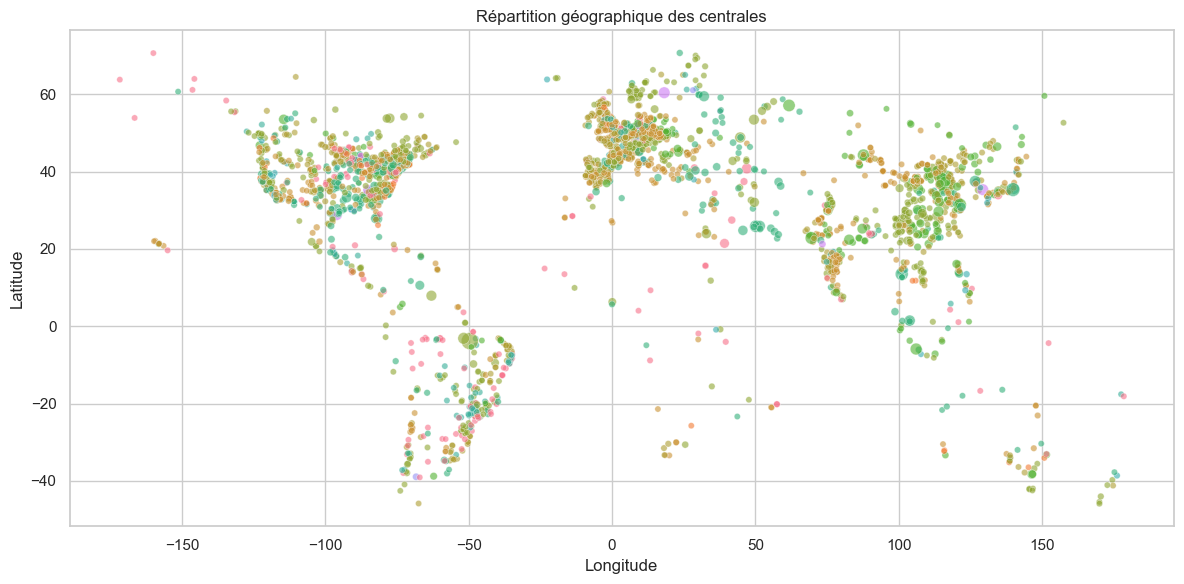

Matrice de covariance :
 [[ 1.68252271e+05  1.66958816e+02  5.01824148e+03]
 [ 1.66958816e+02  5.52519060e+02 -2.12982034e+01]
 [ 5.01824148e+03 -2.12982034e+01  5.99054401e+03]]

Valeurs propres : [168407.48534497   5835.62620702    552.22209672]

Vecteurs propres :
 [[ 9.99522534e-01  3.08770705e-02  1.14435558e-03]
 [ 9.90267746e-04  5.00519479e-03 -9.99986984e-01]
 [ 3.08823963e-02 -9.99510658e-01 -4.97222842e-03]]

Exemples de centrales filtrées de manière complexe :
             name country_long primary_fuel  capacity_mw  latitude  longitude
9      Bistrica 1      Albania        Hydro         27.0   39.9116    20.1047
10         Fierza      Albania        Hydro        500.0   42.2514    20.0431
11          Koman      Albania        Hydro        600.0   42.1033    19.8224
13        Shkopet      Albania        Hydro         24.0   41.6796    19.8305
14           Ulez      Albania        Hydro         25.0   41.6796    19.8936
15    Vau i Dijes      Albania        Hydro        250.

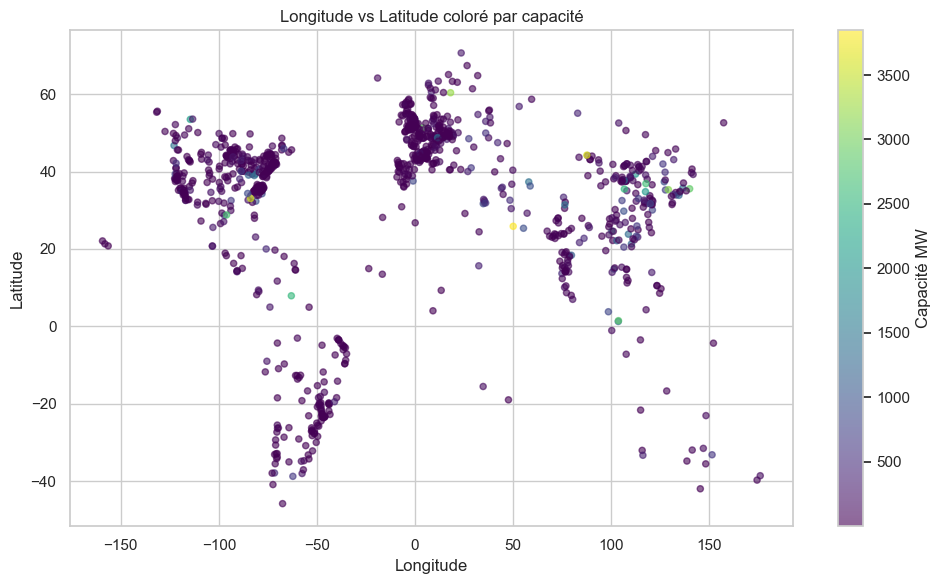

In [5]:
# Répartition géographique des centrales
geo_data = df.dropna(subset=["latitude", "longitude", "primary_fuel", "capacity_mw"]).copy()
geo_sample = geo_data.sample(n=min(3000, len(geo_data)), random_state=42)

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=geo_sample,
    x="longitude",
    y="latitude",
    hue="primary_fuel",
    size="capacity_mw",
    sizes=(20, 150),
    alpha=0.6,
    legend=False,
)
plt.title("Répartition géographique des centrales")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

# Opérations matricielles sur des attributs réels
matrix_data = geo_data[["capacity_mw", "latitude", "longitude"]].sample(n=min(1000, len(geo_data)), random_state=42)
X = matrix_data.to_numpy()
X_centered = X - X.mean(axis=0)
cov_matrix = np.cov(X_centered, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Matrice de covariance :\n", cov_matrix)
print("\nValeurs propres :", eigenvalues)
print("\nVecteurs propres :\n", eigenvectors)

# Filtrage complexe avec NumPy + Pandas
fuel_mask = np.isin(df["primary_fuel"].to_numpy(), ["Hydro", "Solar", "Wind"])
capacity_mask = df["capacity_mw"].to_numpy() > np.nanmedian(df["capacity_mw"])
geo_mask = (df["latitude"].to_numpy() > 0) & (df["longitude"].to_numpy() < 50)
complex_mask = fuel_mask & capacity_mask & geo_mask
filtered_plants = df.loc[complex_mask, ["name", "country_long", "primary_fuel", "capacity_mw", "latitude", "longitude"]]

print("\nExemples de centrales filtrées de manière complexe :")
print(filtered_plants.head(10))

# Visualisation Matplotlib améliorée utilisant des tableaux NumPy
plt.figure(figsize=(10, 6))
plt.scatter(
    matrix_data["longitude"].to_numpy(),
    matrix_data["latitude"].to_numpy(),
    c=matrix_data["capacity_mw"].to_numpy(),
    cmap="viridis",
    alpha=0.6,
    s=20,
)
plt.colorbar(label="Capacité MW")
plt.title("Longitude vs Latitude coloré par capacité")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

## Interprétation des valeurs propres et conclusion

Les valeurs propres résument la variance portée par chaque direction principale de la matrice de covariance. Dans ce contexte, elles aident à comprendre quelles combinaisons de capacité, latitude et longitude structurent le plus fortement les données. Les vecteurs propres indiquent ces directions dominantes et sont utiles pour la réduction de dimension, la détection de structure et la compression d'information.

NumPy complète Pandas pour le filtrage rapide des tableaux et améliore Matplotlib en fournissant des tableaux numériques directement exploitables pour des graphiques plus précis et plus flexibles.